In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [3]:
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

Read the file and prepare data for SVR

In [4]:
file_csv = '../../../../../../../data/phen/original/phenotypic_weather_obregon_151617_fifteen.csv'
print(os.getcwd())
svr = SVR_Prediction(kernel=SvrKernelEnum.RBF)
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

/phen/app/notebooks/phen/pca/phenotypic_weather/svr/fifteen


In [ ]:
file_csv = '../../../../../../../data/phen/original/phenotypic_weather_obregon_151617_fifteen.csv'
print(os.getcwd())
svr = SVR_Prediction(kernel=SvrKernelEnum.RBF)
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

/phen/app/notebooks/phen/pca/phenotypic_weather/svr/fifteen


Launched SVR

In [5]:
x_train, y_train = preprocessing.get_train()
svr.training(x_train=x_train, y_train=y_train)

In [6]:
x_test, y_test = preprocessing.get_test()
y_predicted = svr.prediction(x_test=x_test)

Get metrics

In [7]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 101.94146424575874
R2 -> -0.07891350125810859
MAPE -> 0.1424558691204104


{'d2_absolute_error_score': -0.01342744720540412,
 'd2_pinball_score': -0.01342744720540412,
 'd2_tweedie_score': -0.07891350125810859,
 'explained_variance_score': 0.012612612321086014,
 'max_error': 421.089137111641,
 'mean_absolute_error': 70.71443986010956,
 'mean_absolute_percentage_error': 0.1424558691204104,
 'mean_gamma_deviance': 0.032833941679198175,
 'mean_poisson_deviance': 18.209306701647723,
 'mean_squared_error': 10392.062132569306,
 'mean_squared_log_error': 0.03836340135221061,
 'median_absolute_error': 45.48461945702314,
 'r2_score': -0.07891350125810859,
 'root_mean_squared_error': 101.94146424575874,
 'root_mean_squared_log_error': 0.19586577381515796}

Plots:

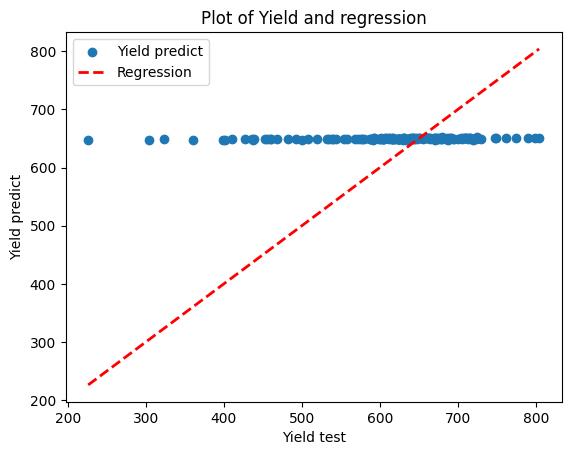

In [8]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = "Plot of Yield and regression"
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)


Plot $r^2$

In [9]:
legend = PlotLegends()
legend.first_plot_label = "{variable}, and yield test"
legend.second_plot_label = "{variable}, and yield predict"
legend.title = "Plot of {variable} ans yield with R2 = {r2:.2f}"
legend.x_label = "{variable}"
legend.y_label = "Yield predict"
features = preprocessing.get_name_features()
#metric.plot_r2_predicted(legend=legend, features=features)

Get the predict that are more bigger that .05

In [10]:
metric.list_percentage_error_upper(pivot=.04, sort = 'error')

[{'truth': 226.1118, 'predict': 647.200937111641, 'error': 1.8623050062475333},
 {'truth': 304.5419,
  'predict': 647.8019989628579,
  'error': 1.1271358685384765},
 {'truth': 322.9881, 'predict': 648.6462505565444, 'error': 1.008266714954961},
 {'truth': 360.0, 'predict': 647.5411456706021, 'error': 0.7987254046405613},
 {'truth': 398.2896,
  'predict': 646.8685875682357,
  'error': 0.6241161897479516},
 {'truth': 400.8056, 'predict': 647.7841698647356, 'error': 0.616205387012396},
 {'truth': 409.865, 'predict': 648.6306391518436, 'error': 0.5825470317100597},
 {'truth': 427.0, 'predict': 648.8207188417085, 'error': 0.5194864609876078},
 {'truth': 436.0, 'predict': 649.0218869177695, 'error': 0.4885823094444255},
 {'truth': 437.0, 'predict': 647.969422913335, 'error': 0.4827675581540848},
 {'truth': 438.9351,
  'predict': 648.638106887847,
  'error': 0.47775401622665187},
 {'truth': 453.0, 'predict': 649.0689081617427, 'error': 0.43282319682503906},
 {'truth': 455.805, 'predict': 649.